In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('husl')

con = duckdb.connect('../data/processed/ecommerce.duckdb')
con.execute("""
    CREATE VIEW IF NOT EXISTS ecommerce_clean AS
    SELECT * FROM read_parquet('../data/processed/ecommerce_clean.parquet')
""")

print("Ready!")

Ready!


In [5]:
rfm = con.execute("""
    WITH max_date AS (
        SELECT MAX(event_date) AS last_date FROM ecommerce_clean
    )
    SELECT
        user_id,
        DATEDIFF('day', MAX(event_date), (SELECT last_date FROM max_date))
                                        AS recency,
        COUNT(DISTINCT user_session)    AS frequency,
        ROUND(SUM(price), 2)            AS monetary
    FROM ecommerce_clean
    GROUP BY user_id
""").df()

print(f"RFM calculated for {len(rfm):,} customers")
print("\nRFM Summary:")
display(rfm[['recency','frequency','monetary']].describe())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RFM calculated for 3,021,435 customers

RFM Summary:


,recency,frequency,monetary
count,"3,021,435.00","3,021,435.00","3,021,435.00"
mean,12.95,3.06,"4,078.82"
std,8.82,6.75,"11,230.70"
min,0.00,1.00,0.77
25%,5.00,1.00,288.24
50%,12.00,2.00,"1,056.97"
75%,20.00,3.00,"3,602.86"
max,31.00,"7,393.00","1,993,636.41"


In [6]:
rfm['R'] = pd.qcut(rfm['recency'],  q=5, labels=[5,4,3,2,1])  
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'),
                   q=5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5])

rfm['R'] = rfm['R'].astype(int)
rfm['F'] = rfm['F'].astype(int)
rfm['M'] = rfm['M'].astype(int)

rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']
rfm['RFM_Label'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

print("RFM Scoring")
display(rfm.head(10))

RFM Scoring


,user_id,recency,frequency,monetary,R,F,M,RFM_Score,RFM_Label
0,513227490,12,5,"9,564.21",3,5,5,13,355
1,512615023,17,4,"4,919.82",2,4,5,11,245
2,555485539,31,2,"22,765.18",1,3,5,9,135
3,555488815,31,1,727.21,1,1,3,5,113
4,537937304,11,8,"5,130.69",3,5,5,13,355
5,514707949,18,5,"2,022.07",2,5,4,11,254
6,515115037,3,11,"33,766.40",5,5,5,15,555
7,555479922,21,6,"4,573.56",2,5,4,11,254
8,512504936,12,6,"3,139.14",3,5,4,12,354
9,547246175,7,31,"107,838.45",4,5,5,14,455


In [7]:
# Mapping RFM Score ke segment bisnis
def segment_customer(row):
    r, f, m = row['R'], row['F'], row['M']
    score   = row['RFM_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'          # Baru beli, sering, spending tinggi
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'    # Konsisten di semua dimensi
    elif r >= 4 and f <= 2:
        return 'New Customers'      # Baru beli tapi belum loyal
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'            # Dulu loyal, sekarang jarang
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'               # Sudah lama tidak beli
    elif m >= 4 and f <= 2:
        return 'Big Spenders'       # Jarang beli tapi nilai tinggi
    elif r >= 3 and score >= 9:
        return 'Potential Loyalist' # Prospek bagus
    else:
        return 'Need Attention'     # Perlu didorong

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Summary per segment
segment_summary = rfm.groupby('Segment').agg(
    total_customers = ('user_id', 'count'),
    avg_recency     = ('recency', 'mean'),
    avg_frequency   = ('frequency', 'mean'),
    avg_monetary    = ('monetary', 'mean'),
    total_revenue   = ('monetary', 'sum')
).round(2).reset_index()

segment_summary['revenue_share'] = (
    segment_summary['total_revenue'] /
    segment_summary['total_revenue'].sum() * 100
).round(2)

segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print("Customer Segment Summary:")
display(segment_summary)

Customer Segment Summary:


,Segment,total_customers,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share
2,Champions,532205,4.02,8.06,"13,110.31","6,977,370,417.13",56.62
4,Loyal Customers,508547,8.97,3.51,"4,395.57","2,235,352,291.34",18.14
0,At Risk,338440,21.34,3.43,"5,193.92","1,757,830,151.89",14.26
1,Big Spenders,137388,21.08,1.00,"4,164.31","572,125,784.52",4.64
6,New Customers,340845,4.99,1.00,"1,000.46","341,000,478.32",2.77
5,Need Attention,571285,16.98,1.28,496.69,"283,752,579.26",2.30
3,Lost,412796,23.92,1.00,225.81,"93,212,368.95",0.76
7,Potential Loyalist,179929,5.68,2.16,351.45,"63,236,102.46",0.51


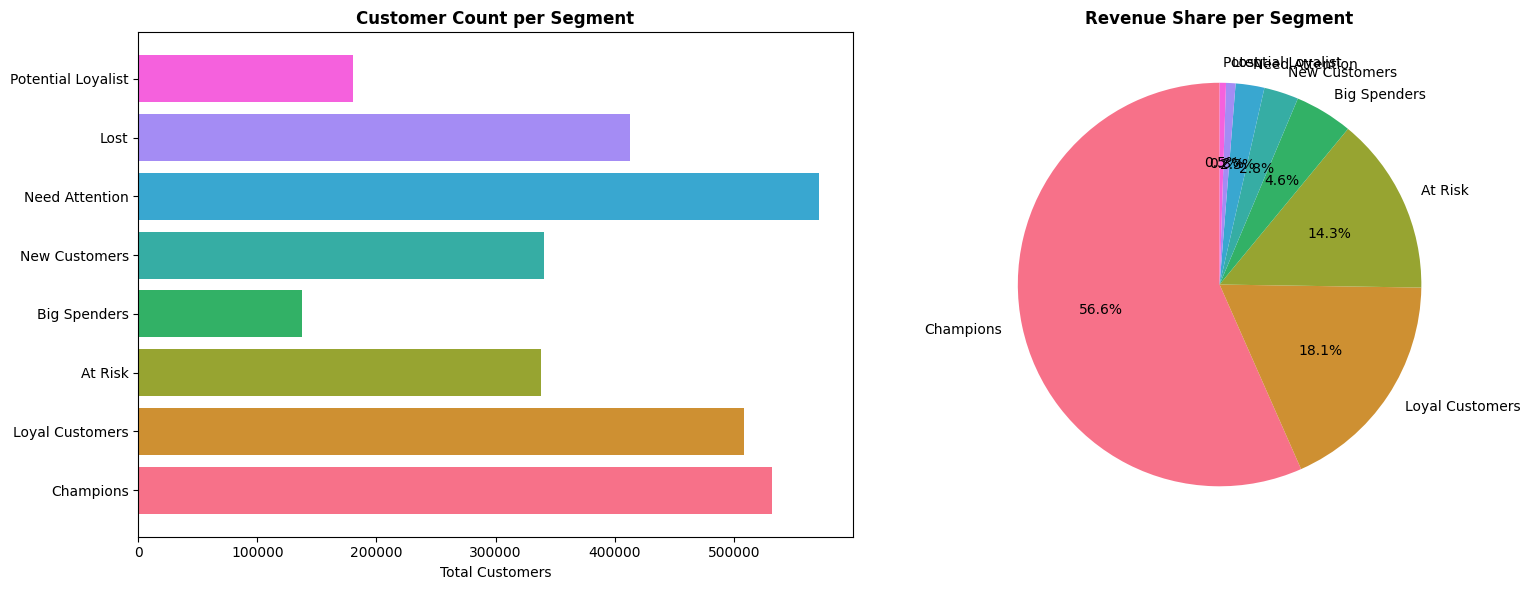

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('husl', len(segment_summary))

# Chart 1 — Customer Count per Segment
axes[0].barh(
    segment_summary['Segment'],
    segment_summary['total_customers'],
    color=colors
)
axes[0].set_title('Customer Count per Segment', fontweight='bold')
axes[0].set_xlabel('Total Customers')

# Chart 2 — Revenue Share per Segment
axes[1].pie(
    segment_summary['revenue_share'],
    labels=segment_summary['Segment'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[1].set_title('Revenue Share per Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/06_segment_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

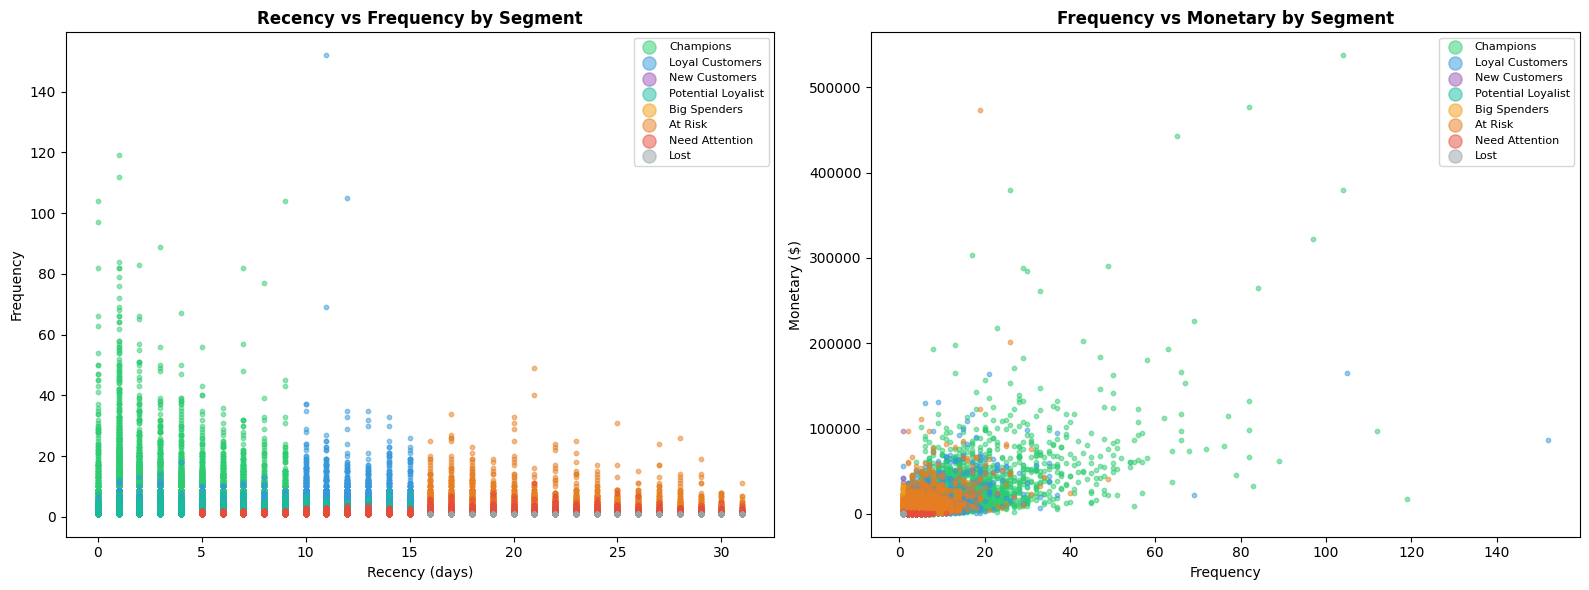

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample 50K agar plot tidak berat
sample = rfm.sample(min(50000, len(rfm)), random_state=42)

segment_colors = {
    'Champions'         : '#2ecc71',
    'Loyal Customers'   : '#3498db',
    'New Customers'     : '#9b59b6',
    'Potential Loyalist': '#1abc9c',
    'Big Spenders'      : '#f39c12',
    'At Risk'           : '#e67e22',
    'Need Attention'    : '#e74c3c',
    'Lost'              : '#95a5a6'
}

for segment, color in segment_colors.items():
    mask = sample['Segment'] == segment
    if mask.sum() > 0:
        axes[0].scatter(
            sample[mask]['recency'],
            sample[mask]['frequency'],
            c=color, label=segment,
            alpha=0.5, s=10
        )

axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Recency vs Frequency by Segment', fontweight='bold')
axes[0].legend(markerscale=3, fontsize=8)

for segment, color in segment_colors.items():
    mask = sample['Segment'] == segment
    if mask.sum() > 0:
        axes[1].scatter(
            sample[mask]['frequency'],
            sample[mask]['monetary'],
            c=color, label=segment,
            alpha=0.5, s=10
        )

axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary ($)')
axes[1].set_title('Frequency vs Monetary by Segment', fontweight='bold')
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/07_rfm_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
recommendations = {
    'Champions'         : 'Reward mereka — loyalty program, early access produk baru',
    'Loyal Customers'   : 'Upsell produk premium — mereka sudah percaya brand',
    'New Customers'     : 'Onboarding campaign — dorong pembelian kedua dalam 7 hari',
    'Potential Loyalist': 'Nurture dengan personalized email & diskon targeted',
    'Big Spenders'      : 'VIP treatment — free shipping, dedicated support',
    'At Risk'           : 'Win-back campaign — "Kami kangen kamu" + diskon eksklusif',
    'Need Attention'    : 'Re-engagement push notification + flash sale alert',
    'Lost'              : 'Aggressive discount atau terima sebagai churn'
}

print("=" * 60)
print("     BUSINESS RECOMMENDATIONS PER SEGMENT")
print("=" * 60)
for segment, rec in recommendations.items():
    count = len(rfm[rfm['Segment'] == segment])
    pct   = count / len(rfm) * 100
    print(f"\n{rec}")
    print(f"   Segment  : {segment}")
    print(f"   Customers: {count:,} ({pct:.1f}%)")
print("=" * 60)

     BUSINESS RECOMMENDATIONS PER SEGMENT

Reward mereka — loyalty program, early access produk baru
   Segment  : Champions
   Customers: 532,205 (17.6%)

Upsell produk premium — mereka sudah percaya brand
   Segment  : Loyal Customers
   Customers: 508,547 (16.8%)

Onboarding campaign — dorong pembelian kedua dalam 7 hari
   Segment  : New Customers
   Customers: 340,845 (11.3%)

Nurture dengan personalized email & diskon targeted
   Segment  : Potential Loyalist
   Customers: 179,929 (6.0%)

VIP treatment — free shipping, dedicated support
   Segment  : Big Spenders
   Customers: 137,388 (4.5%)

Win-back campaign — "Kami kangen kamu" + diskon eksklusif
   Segment  : At Risk
   Customers: 338,440 (11.2%)

Re-engagement push notification + flash sale alert
   Segment  : Need Attention
   Customers: 571,285 (18.9%)

Aggressive discount atau terima sebagai churn
   Segment  : Lost
   Customers: 412,796 (13.7%)


In [11]:
# Simpan hasil RFM untuk dipakai di notebook lain
rfm.to_parquet('../data/processed/rfm_segments.parquet', index=False)

con.close()
print("RFM Analysis selesai!")
print("Saved: data/processed/rfm_segments.parquet")
print("Charts: reports/figures/06 & 07")

RFM Analysis selesai!
Saved: data/processed/rfm_segments.parquet
Charts: reports/figures/06 & 07
